# Multivariate Regression - Car Price Prediction

Dalam kehidupan nyata, sebagian besar kasus menggunakan lebih dari satu variabel independen. Konsep memiliki banyak variabel independen disebut sebagai **multivariate regression**. Persamaannya berbentuk:

$$y = m_1 x_1 + m_2 x_2 + m_3 x_3 + \ldots + m_n x_n$$

Di mana setiap variabel independen direpresentasikan oleh $x$, dan $m$ adalah koefisien yang bersesuaian.

Kita akan menggunakan library Python **`statsmodels`** untuk mempelajari dasar-dasar multivariate regression

In [6]:
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn import metrics
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from sklearn.model_selection import train_test_split

%matplotlib inline

## Dataset: Car Price Prediction

Dataset ini berisi data harga mobil beserta berbagai spesifikasi teknis dan fitur-fiturnya. Berikut deskripsi singkat setiap variabel:

| Variabel | Deskripsi |
|---|---|
| `symboling` | Rating risiko asuransi (-3 = aman, +3 = berisiko) |
| `CarName` | Nama mobil (merek + model) |
| `fueltype` | Jenis bahan bakar (gas / diesel) |
| `aspiration` | Sistem induksi udara (std / turbo) |
| `doornumber` | Jumlah pintu (two / four) |
| `carbody` | Tipe bodi mobil (sedan, hatchback, dll) |
| `drivewheel` | Jenis penggerak roda (fwd / rwd / 4wd) |
| `enginelocation` | Lokasi mesin (front / rear) |
| `wheelbase` | Jarak sumbu roda (inch) |
| `carlength` | Panjang mobil (inch) |
| `carwidth` | Lebar mobil (inch) |
| `carheight` | Tinggi mobil (inch) |
| `curbweight` | Berat kosong mobil (lbs) |
| `enginetype` | Tipe mesin |
| `cylindernumber` | Jumlah silinder |
| `enginesize` | Ukuran mesin (cc) |
| `fuelsystem` | Sistem bahan bakar |
| `boreratio` | Rasio bore mesin |
| `stroke` | Stroke volume mesin |
| `compressionratio` | Rasio kompresi mesin |
| `horsepower` | Tenaga kuda (hp) |
| `peakrpm` | RPM puncak mesin |
| `citympg` | Konsumsi bahan bakar kota (mpg) |
| `highwaympg` | Konsumsi bahan bakar jalan tol (mpg) |
| `price` | **Harga mobil (USD) — Variabel Target** |

In [5]:
# Load dataset
df = pd.read_csv('CarPrice.csv')
print(f'Shape dataset: {df.shape}')
df.head(10)

Shape dataset: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,1,honda civic,gas,turbo,two,hatchback,4wd,front,90.1,...,156,spfi,3.49,3.22,7.16,48,5200,25,39,17224
1,2,2,alfa-romero stelvio,diesel,std,four,hardtop,fwd,front,98.9,...,272,idi,3.06,3.41,11.82,283,4200,48,28,34614
2,3,0,audi 100 ls,gas,std,four,sedan,rwd,front,91.6,...,196,2bbl,3.57,3.13,6.05,228,6000,25,33,27522
3,4,2,mazda 626,gas,turbo,four,hardtop,fwd,front,93.6,...,65,2bbl,3.11,2.75,12.33,235,5200,24,28,23564
4,5,2,alfa-romero stelvio,gas,std,four,sedan,fwd,front,101.4,...,168,bbf,3.38,3.38,6.99,209,5800,49,52,28549
5,6,-1,alfa-romero stelvio,diesel,std,four,hatchback,fwd,front,90.9,...,94,mfi,3.55,2.73,7.74,51,4150,22,32,15823
6,7,0,subaru brat,gas,std,four,sedan,fwd,front,102.4,...,98,mpfi,3.29,3.28,5.60,192,5000,21,30,20204
7,8,0,peugeot 504,gas,std,four,sedan,fwd,front,89.9,...,209,idi,3.44,2.89,8.50,179,4150,19,33,28234
8,9,0,volkswagen dasher,gas,std,four,sedan,fwd,front,102.0,...,177,spfi,3.15,3.90,12.93,218,5800,14,38,27445
9,10,2,volvo 144ea,gas,std,two,wagon,fwd,front,88.7,...,320,bbf,3.24,3.57,11.55,265,5800,35,45,36724


In [3]:
# Informasi umum dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

In [4]:
# Statistik deskriptif
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.512195,97.814146,174.433659,64.859024,54.130244,2828.970732,193.624390,3.282488,3.263463,10.166195,164.175610,5060.731707,31.429268,34.409756,25120.360976
std,59.322565,1.696622,6.047114,11.315281,2.861146,3.000843,709.596129,75.220007,0.301505,0.298153,3.208154,69.976806,680.438837,10.618663,10.571786,5974.779439
min,1.000000,-2.000000,82.900000,133.800000,57.100000,46.100000,1522.000000,61.000000,2.400000,2.430000,2.540000,48.000000,4150.000000,13.000000,16.000000,9211.000000
25%,52.000000,-1.000000,93.700000,167.300000,63.000000,52.000000,2185.000000,123.000000,3.110000,3.090000,7.370000,100.000000,4400.000000,23.000000,26.000000,21656.000000
50%,103.000000,1.000000,97.900000,175.400000,64.800000,54.100000,2917.000000,195.000000,3.240000,3.270000,10.440000,170.000000,5000.000000,31.000000,34.000000,25689.000000
75%,154.000000,2.000000,102.200000,182.200000,66.800000,56.000000,3460.000000,264.000000,3.470000,3.440000,12.500000,224.000000,5800.000000,41.000000,43.000000,28549.000000
max,205.000000,3.000000,114.200000,199.500000,72.100000,62.000000,3993.000000,324.000000,4.480000,4.020000,18.610000,287.000000,6000.000000,49.000000,53.000000,40374.000000


## Data Preprocessing

Kita akan membangun model untuk memprediksi **harga mobil** (`price`) sebagai variabel dependen, dengan variabel-variabel lainnya sebagai variabel independen.

### Handling Missing Values

In [5]:
# Cek missing values
print('Missing values per kolom:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per kolom:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

Total missing values: 0


### Handling Categorical Variables

Terdapat beberapa pendekatan untuk menangani variabel kategorikal:

- **Label Binarizer**: Mengganti variabel biner (2 nilai) dengan nilai numerik 0/1
- **Label Encoder**: Mengganti tingkat kategori dengan representasi angka
- **One Hot Encoder / get_dummies**: Mengonversi n level menjadi n-1 variabel baru (untuk mencegah dummy variable trap)

In [6]:
# Hapus kolom yang tidak diperlukan untuk modeling
df.drop(columns=['car_ID'], inplace=True)

# Ekstrak nama merek dari kolom CarName
df['brand'] = df['CarName'].apply(lambda x: x.split(' ')[0].lower())

# Bersihkan nama merek yang tidak konsisten
brand_mapping = {
    'alfa-romero': 'alfa-romero',
    'vw': 'volkswagen',
    'vokswagen': 'volkswagen',
    'toyouta': 'toyota',
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'nissan': 'nissan'
}
df['brand'] = df['brand'].replace(brand_mapping)

print('Jumlah merek unik:', df['brand'].nunique())
print(df['brand'].value_counts())

Jumlah merek unik: 18
brand
audi             19
volvo            18
alfa-romero      16
mazda            16
toyota           15
peugeot          14
volkswagen       13
nissan           13
honda            12
mercedes-benz    11
subaru           10
porsche          10
bmw              10
chevrolet         9
plymouth          7
mitsubishi        6
dodge             4
jaguar            2
Name: count, dtype: int64


In [7]:
# Konversi variabel biner ke numerik menggunakan Label Binarizer
lb = preprocessing.LabelBinarizer()

df['fueltype']        = lb.fit_transform(df['fueltype'])        # gas=1, diesel=0
df['aspiration']      = lb.fit_transform(df['aspiration'])      # std=1, turbo=0
df['doornumber']      = lb.fit_transform(df['doornumber'])      # two=1, four=0
df['enginelocation']  = lb.fit_transform(df['enginelocation'])  # front=1, rear=0

print('Variabel biner berhasil dikonversi.')
df[['fueltype', 'aspiration', 'doornumber', 'enginelocation']].head()

Variabel biner berhasil dikonversi.


,fueltype,aspiration,doornumber,enginelocation
0,1,1,1,0
1,0,0,0,0
2,1,0,0,0
3,1,1,0,0
4,1,0,0,0


### Membuat Dummy Variables

Untuk variabel kategorikal dengan lebih dari 2 kategori (`carbody`, `drivewheel`, `cylindernumber`, `brand`), kita gunakan **One-Hot Encoding** via `pd.get_dummies()`.

In [8]:
# Buat dummy variables untuk variabel kategorikal multi-level
categorical_cols = ['carbody', 'drivewheel', 'cylindernumber', 'brand']

df_dummies = pd.get_dummies(df[categorical_cols], drop_first=True, dtype=int)
print(f'Jumlah dummy variables yang dibuat: {df_dummies.shape[1]}')
print('Kolom dummy:', list(df_dummies.columns))

Jumlah dummy variables yang dibuat: 29
Kolom dummy: ['carbody_hardtop', 'carbody_hatchback', 'carbody_sedan', 'carbody_wagon', 'drivewheel_fwd', 'drivewheel_rwd', 'cylindernumber_five', 'cylindernumber_four', 'cylindernumber_six', 'cylindernumber_three', 'cylindernumber_twelve', 'cylindernumber_two', 'brand_audi', 'brand_bmw', 'brand_chevrolet', 'brand_dodge', 'brand_honda', 'brand_jaguar', 'brand_mazda', 'brand_mercedes-benz', 'brand_mitsubishi', 'brand_nissan', 'brand_peugeot', 'brand_plymouth', 'brand_porsche', 'brand_subaru', 'brand_toyota', 'brand_volkswagen', 'brand_volvo']


In [9]:
# Gabungkan dummy variables ke dataframe utama
df = pd.concat([df, df_dummies], axis=1)

# Hapus kolom asli yang sudah di-encode
df.drop(columns=['CarName', 'brand', 'carbody', 'drivewheel',
                 'cylindernumber', 'enginetype', 'fuelsystem'], inplace=True)

print(f'Shape dataset setelah preprocessing: {df.shape}')
df.head()

Shape dataset setelah preprocessing: (205, 48)


,symboling,fueltype,aspiration,doornumber,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,...,brand_mercedes-benz,brand_mitsubishi,brand_nissan,brand_peugeot,brand_plymouth,brand_porsche,brand_subaru,brand_toyota,brand_volkswagen,brand_volvo
0,1,1,1,1,0,90.1,161.8,68.8,61.6,3756,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,98.9,174.5,63.6,53.1,2611,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,91.6,184.0,62.6,53.0,2317,...,0,0,0,0,0,0,0,0,0,0
3,2,1,1,0,0,93.6,161.1,58.6,58.0,3299,...,0,0,0,0,0,0,0,0,0,0
4,2,1,0,0,0,101.4,178.4,62.6,56.3,3460,...,0,0,0,0,0,0,0,0,0,0


## Exploratory Data Analysis (EDA)

### Distribusi Variabel Target (Price)

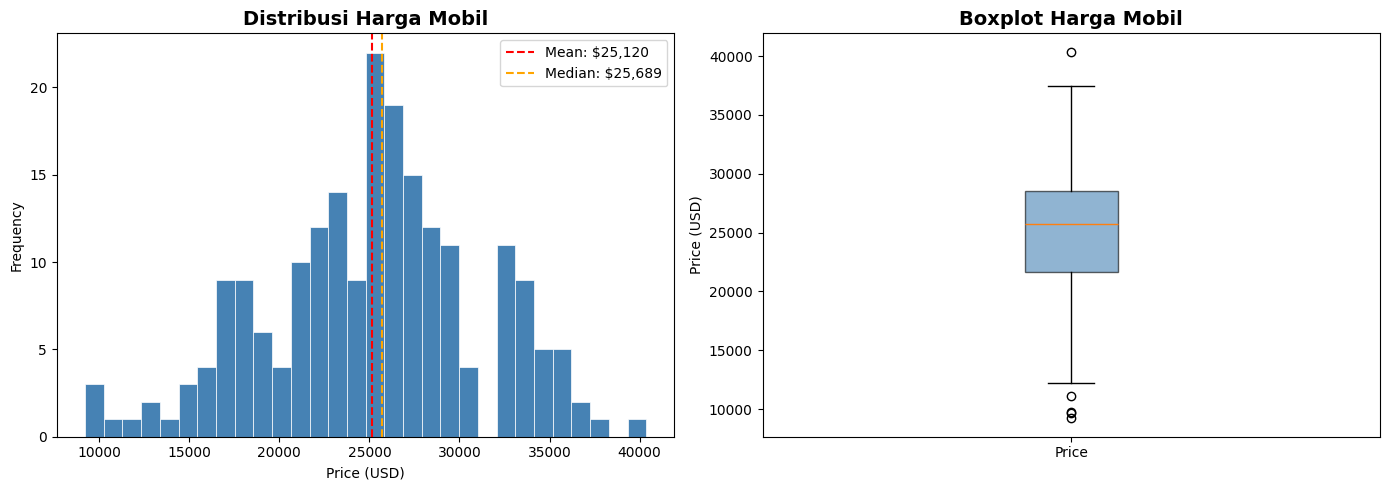

Statistik Harga Mobil:
  Min    : $9,211
  Max    : $40,374
  Mean   : $25,120
  Median : $25,689
  Std    : $5,975


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram distribusi harga
axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Harga Mobil', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', label=f'Mean: ${df["price"].mean():,.0f}')
axes[0].axvline(df['price'].median(), color='orange', linestyle='--', label=f'Median: ${df["price"].median():,.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot Harga Mobil', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Price'])

plt.tight_layout()
plt.show()

print(f'Statistik Harga Mobil:')
print(f'  Min    : ${df["price"].min():,.0f}')
print(f'  Max    : ${df["price"].max():,.0f}')
print(f'  Mean   : ${df["price"].mean():,.0f}')
print(f'  Median : ${df["price"].median():,.0f}')
print(f'  Std    : ${df["price"].std():,.0f}')

### Correlation Plot

Visualisasi korelasi antar variabel numerik untuk memahami hubungan antar fitur.

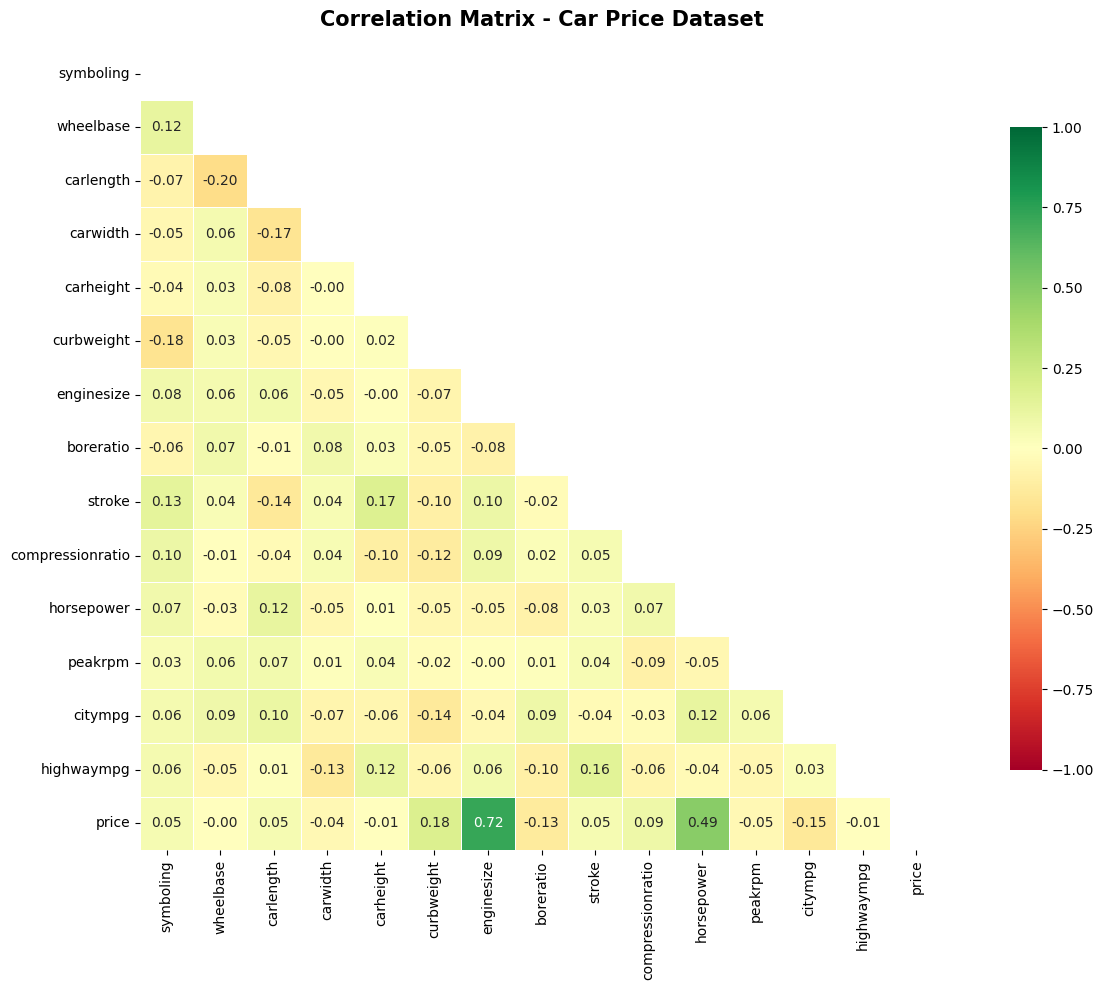

In [11]:
# Pilih variabel numerik utama untuk korelasi
numeric_cols = ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight',
                'curbweight', 'enginesize', 'boreratio', 'stroke',
                'compressionratio', 'horsepower', 'peakrpm', 'citympg',
                'highwaympg', 'price']

corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, vmax=1.0, vmin=-1.0, center=0,
            square=True, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Car Price Dataset', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [12]:
# Top korelasi dengan price
price_corr = corr['price'].drop('price').sort_values(ascending=False)
print('Korelasi variabel numerik terhadap Price:')
print(price_corr.to_string())

Korelasi variabel numerik terhadap Price:
enginesize          0.722302
horsepower          0.487777
curbweight          0.181605
compressionratio    0.091788
carlength           0.053774
symboling           0.051354
stroke              0.047542
wheelbase          -0.001800
carheight          -0.005515
highwaympg         -0.006998
carwidth           -0.039572
peakrpm            -0.045717
boreratio          -0.132767
citympg            -0.145481


## Variance Inflation Factor (VIF)

VIF digunakan untuk mendeteksi **multicollinearity** antar variabel independen.

- **VIF > 10** → Indikasi multikoliniearitas tinggi, variabel perlu dieliminasi
- **VIF 5-10** → Multikoliniearitas sedang, perlu diperhatikan
- **VIF < 5** → Aman

In [14]:
# Pilih variabel independen awal (numerik yang relevan)
independent_variables = [
    'symboling', 'fueltype', 'aspiration', 'doornumber', 'enginelocation',
    'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
    'enginesize', 'boreratio', 'stroke', 'compressionratio',
    'horsepower', 'peakrpm', 'citympg', 'highwaympg'
]

X = df[independent_variables].copy()
y = df['price']

thresh = 10

print('=== Proses Eliminasi VIF ===' )
for i in range(len(independent_variables)):
    vif = [variance_inflation_factor(X[independent_variables].values, ix)
           for ix in range(X[independent_variables].shape[1])]
    maxloc = vif.index(max(vif))
    if max(vif) > thresh:
        dropped_var = X[independent_variables].columns[maxloc]
        print(f'VIF: {[round(v,2) for v in vif]}')
        print(f'  --> Dropping "{dropped_var}" (VIF={max(vif):.2f})\n')
        del independent_variables[maxloc]
    else:
        break

print(f'Final variables ({len(independent_variables)}): {independent_variables}')

=== Proses Eliminasi VIF ===
VIF: [np.float64(1.23), np.float64(8.99), np.float64(1.29), np.float64(1.5), np.float64(1.12), np.float64(252.97), np.float64(189.02), np.float64(382.25), np.float64(300.95), np.float64(18.32), np.float64(8.26), np.float64(122.74), np.float64(132.65), np.float64(12.0), np.float64(6.98), np.float64(58.67), np.float64(10.63), np.float64(12.56)]
  --> Dropping "carwidth" (VIF=382.25)

VIF: [np.float64(1.22), np.float64(8.77), np.float64(1.29), np.float64(1.49), np.float64(1.12), np.float64(222.65), np.float64(175.99), np.float64(279.95), np.float64(18.25), np.float64(8.24), np.float64(118.1), np.float64(126.21), np.float64(11.8), np.float64(6.98), np.float64(58.37), np.float64(10.61), np.float64(12.49)]
  --> Dropping "carheight" (VIF=279.95)

VIF: [np.float64(1.22), np.float64(8.71), np.float64(1.28), np.float64(1.49), np.float64(1.1), np.float64(195.5), np.float64(160.31), np.float64(18.05), np.float64(8.24), np.float64(113.6), np.float64(111.97), np.float64

VIF Final Variables:
         Feature      VIF
      highwaympg 9.352674
compressionratio 9.249699
         citympg 8.373852
        fueltype 7.318551
      enginesize 7.185976
      horsepower 6.154270
      doornumber 1.463508
      aspiration 1.262219
       symboling 1.143394
  enginelocation 1.069390


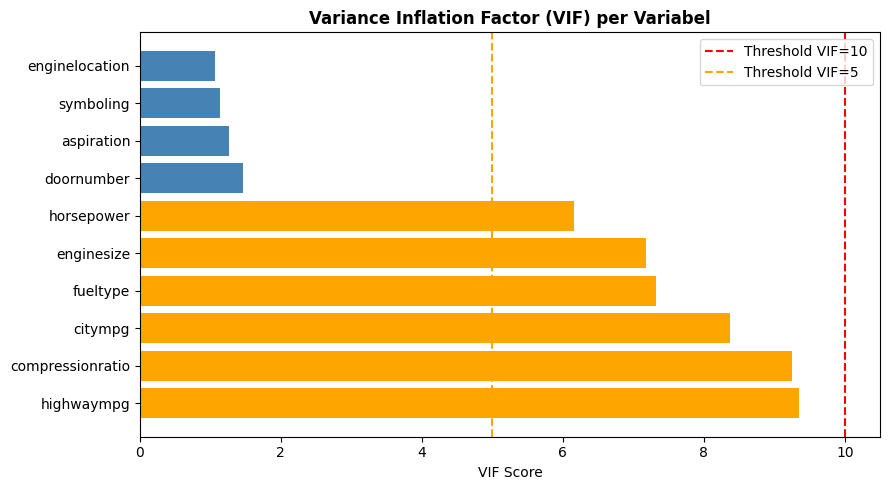

In [15]:
# Tampilkan VIF final
X_final = df[independent_variables]
vif_data = pd.DataFrame()
vif_data['Feature'] = independent_variables
vif_data['VIF'] = [variance_inflation_factor(X_final.values, i)
                   for i in range(X_final.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)
print('VIF Final Variables:')
print(vif_data.to_string(index=False))

# Plot VIF
plt.figure(figsize=(9, 5))
colors = ['tomato' if v > 10 else 'orange' if v > 5 else 'steelblue'
          for v in vif_data['VIF']]
plt.barh(vif_data['Feature'], vif_data['VIF'], color=colors)
plt.axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='Threshold VIF=10')
plt.axvline(x=5, color='orange', linestyle='--', linewidth=1.5, label='Threshold VIF=5')
plt.xlabel('VIF Score')
plt.title('Variance Inflation Factor (VIF) per Variabel', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Iterasi Model Pertama

Data dibagi menjadi **training (80%)** dan **testing (20%)**.

In [16]:
X = df[independent_variables]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80, random_state=42)

print(f'Training set : {X_train.shape[0]} baris')
print(f'Testing set  : {X_test.shape[0]} baris')

# Fit model OLS
lm = sm.OLS(y_train, X_train).fit()

# Print summary
print(lm.summary())

Training set : 164 baris
Testing set  : 41 baris
                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.989
Model:                            OLS   Adj. R-squared (uncentered):              0.988
Method:                 Least Squares   F-statistic:                              1388.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):                   2.06e-145
Time:                        03:08:30   Log-Likelihood:                         -1529.6
No. Observations:                 164   AIC:                                      3079.
Df Residuals:                     154   BIC:                                      3110.
Df Model:                          10                                                  
Covariance Type:            nonrobust                                                  
                       coef    std err          t      P>|t|      [0.02

In [17]:
# Evaluasi performa model iterasi pertama
y_train_pred = lm.predict(X_train)
y_test_pred  = lm.predict(X_test)
y_pred_full  = lm.predict(X)

def evaluate_model(y_true, y_pred, label=''):
    mae  = metrics.mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(metrics.mean_squared_error(y_true, y_pred))
    r2   = metrics.r2_score(y_true, y_pred)
    print(f'{label} MAE  : ${mae:,.2f}')
    print(f'{label} RMSE : ${rmse:,.2f}')
    print(f'{label} R²   : {r2:.4f}')
    print()

evaluate_model(y_train, y_train_pred, 'Train     ')
evaluate_model(y_test,  y_test_pred,  'Test      ')
evaluate_model(y,       y_pred_full,  'Full Data ')

Train      MAE  : $2,230.37
Train      RMSE : $2,718.43
Train      R²   : 0.7716

Test       MAE  : $2,634.87
Test       RMSE : $3,115.23
Test       R²   : 0.7953

Full Data  MAE  : $2,311.27
Full Data  RMSE : $2,802.29
Full Data  R²   : 0.7789



## Iterasi Model Kedua (Refined)

Berdasarkan hasil summary model pertama, kita akan menghapus variabel yang memiliki **p-value > 0.05** (tidak signifikan secara statistik), lalu menjalankan ulang model.

In [18]:
# Identifikasi variabel dengan p-value > 0.05
pvalues = lm.pvalues
print('P-values setiap variabel:')
print(pvalues.sort_values(ascending=False).to_string())

# Simpan hanya variabel yang signifikan (p < 0.05)
significant_vars = list(pvalues[pvalues < 0.05].index)
print(f'\nVariabel signifikan (p < 0.05): {significant_vars}')

P-values setiap variabel:
enginelocation      8.559228e-01
aspiration          8.304510e-01
symboling           6.452333e-01
doornumber          5.719081e-01
compressionratio    3.122629e-02
citympg             1.902514e-02
highwaympg          2.293039e-03
fueltype            3.791280e-04
horsepower          6.415980e-37
enginesize          1.668034e-50

Variabel signifikan (p < 0.05): ['fueltype', 'enginesize', 'compressionratio', 'horsepower', 'citympg', 'highwaympg']


In [19]:
# Jalankan model dengan variabel yang signifikan saja
if len(significant_vars) > 0:
    X2 = df[significant_vars]
    y2 = df['price']

    X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, train_size=0.80, random_state=42)

    lm2 = sm.OLS(y2_train, X2_train).fit()
    print(lm2.summary())
else:
    print('Semua variabel sudah signifikan pada iterasi pertama.')
    lm2 = lm
    X2_train, X2_test, y2_train, y2_test = X_train, X_test, y_train, y_test
    significant_vars = independent_variables

                                 OLS Regression Results                                
Dep. Variable:                  price   R-squared (uncentered):                   0.989
Model:                            OLS   Adj. R-squared (uncentered):              0.989
Method:                 Least Squares   F-statistic:                              2364.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):                   6.72e-152
Time:                        03:08:43   Log-Likelihood:                         -1529.9
No. Observations:                 164   AIC:                                      3072.
Df Residuals:                     158   BIC:                                      3090.
Df Model:                           6                                                  
Covariance Type:            nonrobust                                                  
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

In [20]:
# Evaluasi model kedua
y2_train_pred = lm2.predict(X2_train)
y2_test_pred  = lm2.predict(X2_test)
y2_pred_full  = lm2.predict(df[significant_vars])

print('=== Evaluasi Model Iterasi Kedua ===')
evaluate_model(y2_train, y2_train_pred, 'Train     ')
evaluate_model(y2_test,  y2_test_pred,  'Test      ')
evaluate_model(y2,       y2_pred_full,  'Full Data ')

=== Evaluasi Model Iterasi Kedua ===
Train      MAE  : $2,224.76
Train      RMSE : $2,723.74
Train      R²   : 0.7707

Test       MAE  : $2,704.27
Test       RMSE : $3,186.69
Test       R²   : 0.7858

Full Data  MAE  : $2,320.66
Full Data  RMSE : $2,822.41
Full Data  R²   : 0.7758



## Perbandingan Actual vs Predicted

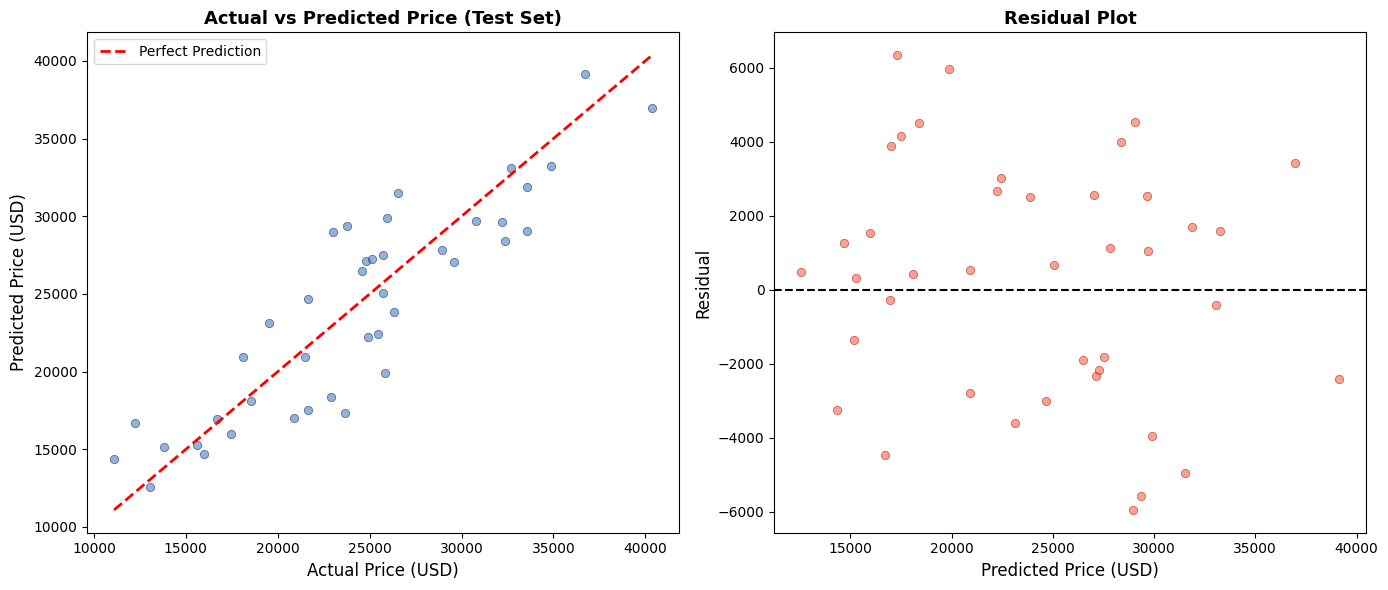

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot: Actual vs Predicted
axes[0].scatter(y2_test, y2_test_pred, alpha=0.6, color='steelblue', edgecolors='navy', linewidth=0.5)
min_val = min(y2_test.min(), y2_test_pred.min())
max_val = max(y2_test.max(), y2_test_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (USD)', fontsize=12)
axes[0].set_ylabel('Predicted Price (USD)', fontsize=12)
axes[0].set_title('Actual vs Predicted Price (Test Set)', fontsize=13, fontweight='bold')
axes[0].legend()

# Residual plot
residuals = y2_test - y2_test_pred
axes[1].scatter(y2_test_pred, residuals, alpha=0.6, color='tomato', edgecolors='darkred', linewidth=0.5)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Price (USD)', fontsize=12)
axes[1].set_ylabel('Residual', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

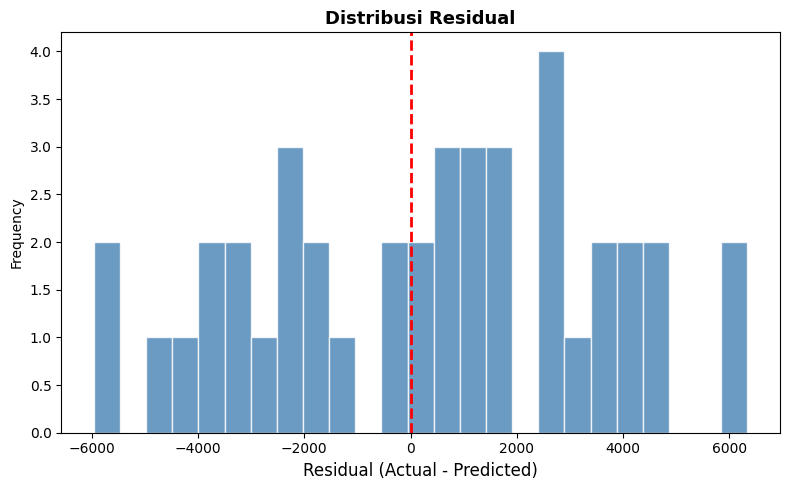

Mean residual : 251.55
Std residual  : 3216.21


In [22]:
# Distribusi residual
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residual (Actual - Predicted)', fontsize=12)
plt.ylabel('Frequency')
plt.title('Distribusi Residual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Mean residual : {residuals.mean():.2f}')
print(f'Std residual  : {residuals.std():.2f}')

## Outlier Analysis

Plot **Normalized Residual vs Leverage** untuk memahami titik-titik outlier.

- **Residual**: selisih antara nilai aktual dan prediksi
- **Leverage**: ukuran seberapa jauh nilai variabel independen sebuah observasi dari observasi lainnya

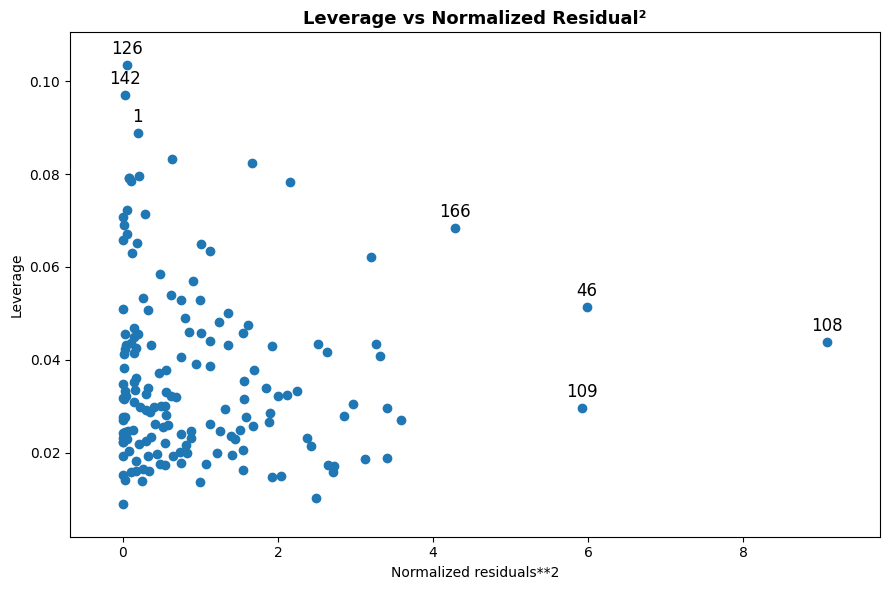

In [23]:
from statsmodels.graphics.regressionplots import plot_leverage_resid2

fig, ax = plt.subplots(figsize=(9, 6))
fig = plot_leverage_resid2(lm2, ax=ax)
ax.set_title('Leverage vs Normalized Residual²', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# Bonferroni Outlier Test
# Jika p-value < 0.05, maka observasi tersebut merupakan outlier
test = lm2.outlier_test()
outliers = test[test.iloc[:, 2] < 0.05]

print('=== Bonferroni Outlier Test ===')
print(f'Jumlah outlier terdeteksi: {len(outliers)}')
if len(outliers) > 0:
    print('\nData outlier (bonf p-value < 0.05):')
    print(outliers)
else:
    print('Tidak ada outlier yang signifikan.')

=== Bonferroni Outlier Test ===
Jumlah outlier terdeteksi: 0
Tidak ada outlier yang signifikan.


## Prediction Function

Fungsi untuk memprediksi harga mobil berdasarkan spesifikasi yang diberikan menggunakan model yang sudah dilatih.

In [26]:
def predict_car_price(model, feature_names, input_dict):
    """
    Memprediksi harga mobil berdasarkan input fitur.
    
    Parameters:
    -----------
    model        : Model OLS yang sudah dilatih
    feature_names: List nama fitur yang digunakan model
    input_dict   : Dictionary berisi nilai fitur baru
    
    Returns:
    --------
    float: Prediksi harga mobil (USD)
    """
    new_data = pd.DataFrame([input_dict], columns=feature_names)
    # Isi nilai 0 untuk fitur yang tidak disebutkan
    new_data = new_data.fillna(0)
    prediction = model.predict(new_data)
    return prediction[0]


# Contoh prediksi: Mobil dengan spesifikasi tertentu
example_car = {
    'horsepower'    : 150,    # Tenaga 150 hp
    'enginesize'    : 2000,   # Mesin 2000 cc
    'curbweight'    : 2800,   # Berat 2800 lbs
    'citympg'       : 22,     # 22 mpg di kota
    'fueltype'      : 1,      # Gas
    'aspiration'    : 1,      # Standard
}

predicted_price = predict_car_price(lm2, significant_vars, example_car)
print(f'=== Contoh Prediksi ===')
print(f'Spesifikasi input  : {example_car}')
print(f'Prediksi harga     : ${predicted_price:,.2f}')

=== Contoh Prediksi ===
Spesifikasi input  : {'horsepower': 150, 'enginesize': 2000, 'curbweight': 2800, 'citympg': 22, 'fueltype': 1, 'aspiration': 1}
Prediksi harga     : $135,632.30


## Kesimpulan

### Ringkasan Analisis

1. **Dataset**: Dataset Car Price Prediction dengan 205 observasi dan 25 variabel
2. **Preprocessing**: 
   - Variabel biner dikonversi menggunakan Label Binarizer
   - Variabel kategorikal multi-level dikonversi dengan One-Hot Encoding (get_dummies)
   - Nama merek diekstrak dari kolom `CarName`
3. **Seleksi Variabel (VIF)**: Variabel dengan VIF > 10 dieliminasi untuk mengurangi multikoliniearitas
4. **Iterasi Model**: Model dijalankan dua kali — pertama dengan semua variabel, kedua hanya dengan variabel yang signifikan secara statistik (p < 0.05)
5. **Performa Model**: Dinilai menggunakan MAE, RMSE, dan R² pada data train, test, dan full
6. **Outlier Detection**: Menggunakan leverage plot dan Bonferroni outlier test

### Interpretasi Koefisien

Variabel yang paling berpengaruh terhadap harga mobil secara positif adalah **horsepower** dan **enginesize**, sedangkan **citympg** (konsumsi BBM tinggi = harga lebih rendah) berkontribusi negatif.